# CENG463 PA1

In this programming assignment, we want to walk you through the building blocks of natural language processing before the success of neural models. You will be working on text preprocessing, textual data representation methods such as bag-of-words, and traditional ML training pipelines.

You will use Python for this task. You can use libraries such as `pandas`, `nltk`, `scikit-learn` etc. for your implementations, or implement your own functions. However, you are expected to analyse and reason about your implementation and results. 

### IMPORTANT NOTE

Do not move or delete the given cells, only add cells inbetween the questions for your answers.

In [48]:
# UPDATE THIS CELL TO INSTALL NEEDED LIBRARIES.
# MAKE SURE TO ADD EVERYTHING THAT NEEDS TO BE INSTALLED IN THIS CELL!

# we will use pip to install packages - you can add others below
!pip install pandas
!pip install nltk
!pip install scikit-learn
!pip install matplotlib

# and import them here - you can add others below
import pandas as pd
import re
import matplotlib.pyplot as plt
import nltk
from nltk.util import ngrams
import os

## Q1 - Special token extraction with regular expressions (10 points)

Load the `old_tweets.csv` file shared with you. Use regular expressions to capture the following:

- usernames (starting with '@', followed by at least 4, at most 15 alphanumeric characters and '_')
- hashtags (starting with '#' followed by any number of alphanumeric characters)
- numbers (different number notations may be captured, such as "1", ".004", "3:00" and "100,323")
- emojis 

#### Notes and tips

- First tokenizing each tweet by space may be a better approach than using a library tokenizer.
- You can use the [re](https://docs.python.org/3/library/re.html) module to implement your solutions.
- Do not forget to add comments to your code.

In [7]:
# need to combine each column beacuse of 9,31 number format
with open('data/old_tweets.csv', 'r', encoding='utf-8') as f:
    tweets = [line.strip() for line in f]

usernames = []
hashtags = []
numbers = []
emojis = []

In [8]:
# Q1 - implementation
# you can add cells below if needed


In [10]:
def find_usernames(tweet, usernames):
    def is_alphanumeric_or_underscore(s):
        return all(c.isalnum() or c == '_' for c in s)
    candidates = re.findall(r'@(\w+)', tweet)
    for candidate in candidates:
        if(len(candidate) <= 15 and len(candidate) >= 4 and is_alphanumeric_or_underscore(candidate)): #alphanumeric and. _ check
            usernames.append(candidate)

def find_hashtags(tweet, hashtags):
    def is_alphanumeric_or_underscore(s):
        return all(c.isalnum() for c in s)
    candidates = re.findall(r'#(\w+)', tweet)
    for candidate in candidates:
        if(is_alphanumeric_or_underscore(candidate)):
            hashtags.append(candidate)

emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # Emoticons
    "\U0001F300-\U0001F5FF"  # Symbols & pictographs
    "\U0001F680-\U0001F6FF"  # Transport & map symbols
    "\U0001F1E0-\U0001F1FF"  # Flags
    "\U00002700-\U000027BF"  # Dingbats
    "\U0001F900-\U0001F9FF"  # Supplemental Symbols & Pictographs
    "]+",
    flags=re.UNICODE
)

def find_emojis(tweet, emojis):
     emos = emoji_pattern.findall(tweet)
     for emo in emos:
         emojis.append(emo)

def find_numbers(tweet, numbers):
    tokens = tweet.split(" ")
    for token in tokens:
        allowed = "0123456789.,:"
        if all(c in allowed for c in token) and any(c.isdigit() for c in token):
            numbers.append(token)

In [11]:
for tweet in tweets:
    tweet = str(tweet)
    find_usernames(tweet, usernames)
    find_hashtags(tweet, hashtags)
    find_emojis(tweet, emojis)
    find_numbers(tweet, numbers)


In [12]:
print(sorted(usernames))
print(sorted(hashtags))
print(sorted(numbers))
print(sorted(emojis))

['071304Nathan', '143percentspeed', '16_vica', '2minbeachclean', '3gerardpique', 'ABCTV', 'ARTSEDNC', 'AWilliamson54', 'ActionBronson', 'ActuallyNPH', 'AdamBaldwin', 'AdamZHerman', 'Afi_licious', 'Agrivisor', 'Agrivisor', 'AishaRuby85', 'AlanLCross', 'Alanis', 'AlaskaAir', 'AlbinomiteMM4', 'AldridgeSec', 'AlistairBurtUK', 'AlmightyTeemo97', 'AndreSavelio', 'AndrewGoldman_I', 'AnewPerspective', 'AnthonyMuraco', 'AppleSupport', 'AquaRumi9', 'ArriFaun', 'Arron_banks', 'Arsenal', 'Asli_Jacqueline', 'AuSenate', 'AvrilLavigne', 'BBCBreakfast', 'BBCBreaking', 'BBCNews', 'BCFC_Community', 'BLUpfront', 'BWANA86a', 'Bemannn', 'BethRigby', 'BethellMarilyn', 'BettyBowers', 'Bienvenuebrexit', 'BloodMoonSaint', 'Bob_Lawblaw', 'BollyBigBolt', 'Bombardier', 'BradMossEsq', 'BrokenSStudios', 'BroxtonDaniel', 'BryanHoch', 'BugsySeigal', 'ButUCanCallMeZ', 'CBSNews', 'CJamesFelts', 'COFFEECOWal', 'CPC_HQ', 'CakedaddyINTL', 'CamilaLolie97', 'Camila_Cabello', 'CaptainsLog2017', 'CaxtonSupport', 'ChadHoy', 'C

## Q2 - Ngrams and perplexity (40 points)

For this task, you will use the `user_reviews_train.csv` file as a corpus to train N-gram language models for N=1 to N=20. Then you will calculate and plot the following:

- Perplexity scores of the trained N-gram LMs for the first review in `user_reviews_test.csv`
- Perplexity scores of the trained N-gram LMs for `trip_review.txt`, which is a "domain-shift" for our LM.

How does our small model perform? Explain the plots and discuss your findings.

#### Notes and tips

- One approach may be using the [`nltk` LM interface](https://www.nltk.org/api/nltk.lm.api.html#module-nltk.lm.api) to implement the language model and calculate perplexity scores.
- You may follow other approaches, but make sure to explain your work in the discussion and by adding comments in your code.

In [13]:
# Q2 - implementation
# you can add cells below if needed

# used for plots, fill them in accordingly
perplexities_user_review = []
perplexities_trip_review = []

# write your code below

In [50]:
# Load training data

train_data = pd.read_csv('data/user_review_train.csv')
train_corpus = train_data['review'].astype(str).tolist()

test_data = pd.read_csv('data/user_review_test.csv')
test_corpus = test_data['review'].astype(str).tolist()

# Domain shift data read txt file
with open("data/trip_review.txt", "r") as f:
    trip_text = f.read()

In [53]:
len(trip_text), trip_text

(429,
 'Really overpriced and actually nothing more than the caves you can see for free outside of the museum. Most churches were closed anyways and to the special ones you have to again pay a fee even tho you already paid an entry fee to the museum. They also removed all information signs about the caves so that you will buy an additional audio guide. At the entry there are many guide molesting you trying to deceive you into a tour.')

In [54]:
# Clean the text data
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\@\w+|\#','', text) 
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip() # remove extra spaces
    return text

cleaned_train_corpus = [clean_text(review) for review in train_corpus]
cleaned_test_corpus = [clean_text(review) for review in test_corpus]
cleaned_trip_corpus = clean_text(trip_text).split('\n')


In [57]:
len(cleaned_trip_corpus) , cleaned_trip_corpus

(1,
 ['really overpriced and actually nothing more than the caves you can see for free outside of the museum most churches were closed anyways and to the special ones you have to again pay a fee even tho you already paid an entry fee to the museum they also removed all information signs about the caves so that you will buy an additional audio guide at the entry there are many guide molesting you trying to deceive you into a tour'])

In [58]:
tokenized_train = [nltk.tokenize.word_tokenize(sentence) for sentence in cleaned_train_corpus]
tokenized_test = [nltk.tokenize.word_tokenize(sentence) for sentence in cleaned_test_corpus]
tokenized_trip = [nltk.tokenize.word_tokenize(sentence) for sentence in cleaned_trip_corpus]

len(tokenized_train), len(tokenized_test), len(tokenized_trip)

(14675, 1675, 1)

In [59]:
perplexities_test = []
perplexities_trip = []

for n in range(1, 21):
    # prepare data for this n
    train_data, vocab = nltk.lm.preprocessing.padded_everygram_pipeline(n, tokenized_train)
    
    # train the model
    model = nltk.lm.Laplace(n)
    model.fit(train_data, vocab)
    
    # test 1: first review in test.csv
    test_data_1, _ = nltk.lm.preprocessing.padded_everygram_pipeline(n, tokenized_test)
    ppl_test = model.perplexity(next(test_data_1))
    perplexities_test.append(ppl_test)
    
    # test 2: trip review (domain-shift)
    test_data_2, _ = nltk.lm.preprocessing.padded_everygram_pipeline(n, tokenized_trip)
    ppl_trip = model.perplexity(next(test_data_2))
    perplexities_trip.append(ppl_trip)

    print(f"N={n} | Test perplexity={ppl_test:.2f} | Trip perplexity={ppl_trip:.2f}")

N=1 | Test perplexity=905.51 | Trip perplexity=2386.15
N=2 | Test perplexity=1497.54 | Trip perplexity=4070.49
N=3 | Test perplexity=2427.29 | Trip perplexity=5859.20
N=4 | Test perplexity=3147.20 | Trip perplexity=6867.44
N=5 | Test perplexity=3611.95 | Trip perplexity=7235.86
N=6 | Test perplexity=3894.91 | Trip perplexity=7242.99
N=7 | Test perplexity=4050.83 | Trip perplexity=7051.74
N=8 | Test perplexity=4120.45 | Trip perplexity=6755.98
N=9 | Test perplexity=4131.02 | Trip perplexity=6410.17
N=10 | Test perplexity=4101.01 | Trip perplexity=6046.13
N=11 | Test perplexity=4043.12 | Trip perplexity=5682.38
N=12 | Test perplexity=3966.22 | Trip perplexity=5329.51
N=13 | Test perplexity=3876.61 | Trip perplexity=4993.31
N=14 | Test perplexity=3778.79 | Trip perplexity=4676.65
N=15 | Test perplexity=3676.02 | Trip perplexity=4380.61
N=16 | Test perplexity=3570.67 | Trip perplexity=4105.21
N=17 | Test perplexity=3464.45 | Trip perplexity=3849.81
N=18 | Test perplexity=3358.61 | Trip per

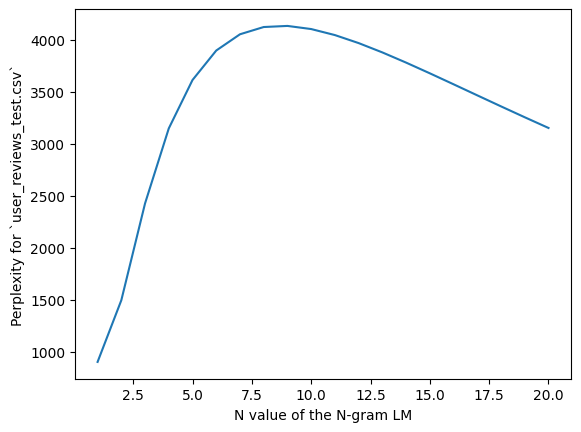

In [63]:
# Q2 - plot for `user_reviews_test.csv`

x = range(1,21,1)
y = perplexities_test

plt.plot(x, y)

plt.xlabel("N value of the N-gram LM")
plt.ylabel("Perplexity for `user_reviews_test.csv`")

plt.show()

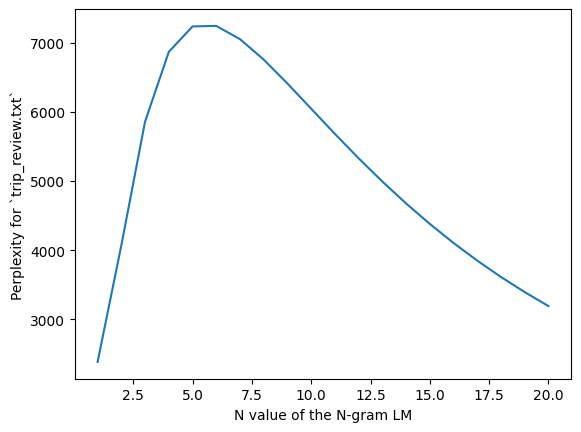

In [61]:
# Q2 - plot for `trip_review.txt`

x = range(1,21,1)
y = perplexities_trip

plt.plot(x, y)

plt.xlabel("N value of the N-gram LM")
plt.ylabel("Perplexity for `trip_review.txt`")

plt.show()

In [62]:
perplexities_test_MLE = []
perplexities_trip_MLE = []

for n in range(1, 21):
    # prepare data for this n
    train_data, vocab = nltk.lm.preprocessing.padded_everygram_pipeline(n, tokenized_train)
    
    # train the model
    model = nltk.lm.MLE(n)
    model.fit(train_data, vocab)
    
    # test 1: first review in test.csv
    test_data_1, _ = nltk.lm.preprocessing.padded_everygram_pipeline(n, tokenized_test)
    ppl_test = model.perplexity(next(test_data_1))
    perplexities_test_MLE.append(ppl_test)
    
    # test 2: trip review (domain-shift)
    test_data_2, _ = nltk.lm.preprocessing.padded_everygram_pipeline(n, tokenized_trip)
    ppl_trip = model.perplexity(next(test_data_2))
    perplexities_trip_MLE.append(ppl_trip)

    print(f"N={n} | Test perplexity={ppl_test:.2f} | Trip perplexity={ppl_trip:.2f} for MLE")

N=1 | Test perplexity=905.59 | Trip perplexity=inf for MLE
N=2 | Test perplexity=225.04 | Trip perplexity=inf for MLE
N=3 | Test perplexity=59.89 | Trip perplexity=inf for MLE
N=4 | Test perplexity=23.26 | Trip perplexity=inf for MLE
N=5 | Test perplexity=12.58 | Trip perplexity=inf for MLE
N=6 | Test perplexity=8.32 | Trip perplexity=inf for MLE
N=7 | Test perplexity=6.18 | Trip perplexity=inf for MLE
N=8 | Test perplexity=4.94 | Trip perplexity=inf for MLE
N=9 | Test perplexity=4.15 | Trip perplexity=inf for MLE
N=10 | Test perplexity=3.61 | Trip perplexity=inf for MLE
N=11 | Test perplexity=3.22 | Trip perplexity=inf for MLE
N=12 | Test perplexity=2.92 | Trip perplexity=inf for MLE
N=13 | Test perplexity=2.69 | Trip perplexity=inf for MLE
N=14 | Test perplexity=2.51 | Trip perplexity=inf for MLE
N=15 | Test perplexity=2.37 | Trip perplexity=inf for MLE
N=16 | Test perplexity=2.24 | Trip perplexity=inf for MLE
N=17 | Test perplexity=2.14 | Trip perplexity=inf for MLE
N=18 | Test perp

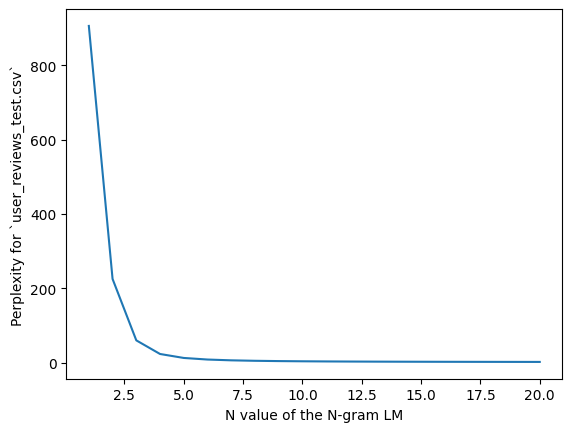

In [64]:
x = range(1,21,1)
y = perplexities_test_MLE

plt.plot(x, y)

plt.xlabel("N value of the N-gram LM")
plt.ylabel("Perplexity for `user_reviews_test.csv`")

plt.show()

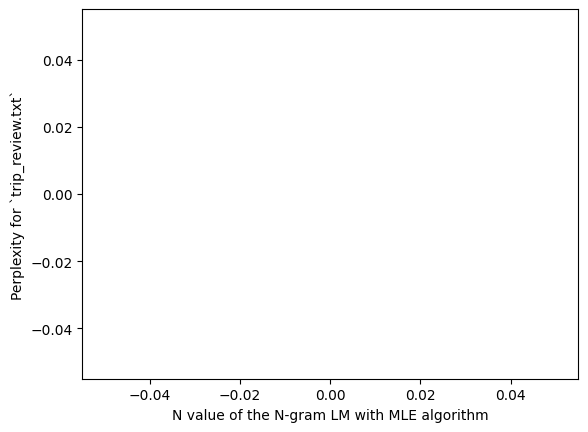

In [65]:
x = range(1,21,1)
y = perplexities_trip_MLE

plt.plot(x, y)

plt.xlabel("N value of the N-gram LM with MLE algorithm")
plt.ylabel("Perplexity for `trip_review.txt`")

plt.show()

### Q2 - Discussion

I implement N-Gram Language Models with different algorithms which are MLE (Maximum Likelihood Estimation) and Laplace.

In both algorithm one can see that how N becomes larger the results become more accurate by monitoring how perplexity score decreases eventually in both algorithms and also in both test and domain-switch cases.

When we compare the algorithms for better performance,

we see that MLE algorithm works fine for our test set and get very low perplexity score at N=20 (1.91) which means that our N-Gram Language Models work fine for our test data. However, we can also see the opposite behaviour at the domain-switch case. Since our model hasn't seen lots of words in the Trip corpus before, the probability score of those unseen words are eventually zero (0) and the perplexity score converges to INFINITY. 

$P(\text{"hotel"} \mid \text{"this was"} = 0)$ 

$$
\text{Perplexity} = 2^{ - \frac{1}{N} \sum \log_2 P(w_i \mid context) }
$$

If any $P(w_i \mid context) = 0$, then $\log P(w_i \mid context) = -\infty$.

On the other hand, the Laplace algorithm puts some smoothing to this perplexity calculation so that we got more clever results for unseen words but this brings trade-offs for our test corpus. One can see higher perplexity score than MLE algorithm for test corpus.

$$
P(w_i \mid context) = \frac{count(context, w_i) + 1}{count(context) + V}
$$

My choice is Laplace theorem actually.

#### Why Laplace Is the Right Choice Here

In this assignment, we train **20 separate language models (N = 1 → 20)** on a relatively **small dataset** (`user_reviews_train.csv`).

For large N (e.g., N > 5), the number of possible n-grams grows exponentially, and many combinations are **never seen** in training.

That means:

- **MLE models** will assign **many zero probabilities**, leading to **infinite perplexities**.
- **Laplace models** will keep results **stable and comparable** across N values.

Thus, **Laplace smoothing** is a **practical and safe choice** for this assignment.


## Q3 - Classifying user reviews using Bag-of-Words (50 points)

For this final task, you will use the `user_reviews_train.csv` and `user_reviews_test.csv` files to implement a binary classifier with Bag-of-Words representation. 

The given dataset includes user reviews and corresponding `sentiment` value for each review, either `1` meaning positive or `0` meaning negative. With this dataset, you are expected to implement a classifier that decides whether a given user review is positive or negative. 

### Part A - Analysis

In this part, you will analyse the training set given in the `user_reviews_train.csv` file to answer these questions:

- How many instances are there for each class?
- What is the minimum, maximum, and average character length of the reviews?
- Does the average length of a review depend heavily on the class label?
- Any other statistics you can report with minimal processing?

You can use tables or draw plots to show your analyses.

### Part B - Implementation

The goal of this part is not to get the highest possible performance, but to see the effect of changing the text representation. Hence, you will train six models: 

- `lighlty_preprocessed_most_15`
- `lighlty_preprocessed_most_100`
- `fully_preprocessed_most_15`
- `fully_preprocessed_most_100`
- `fully_preprocessed_most_500`
- `fully_preprocessed_least_15`

For the `lighlty_preprocessed_most_N` models, the preprocessing steps are as follows:

- Tokenize the reviews by separating from whitespaces.
- Lowercase all tokens for normalization.
- Order all unique tokens by frequency, take the most frequently used N.
- Use these N words as the corpus for Bag-of-Words representation.

For the `fully_preprocessed_most_N` models, the preprocessing steps are as follows:

- Tokenize the reviews by using `word_tokenize()` from `nltk.tokenize`.
- Lowercase all tokens for normalization.
- Remove stopwords by using `stopwords` from `nltk.corpus`.
- Apply lematization to tokens by using `WordNetLemmatizer` from `nltk.stem`. 
- Order all unique tokens by frequency, take the most frequently used N.
- Use these N words as the corpus for Bag-of-Words representation.

For the `fully_preprocessed_least_15` model, the preprocessing steps are as follows:

- Tokenize the reviews by using `word_tokenize()` from `nltk.tokenize`.
- Lowercase all tokens for normalization.
- Remove stopwords by using `stopwords` from `nltk.corpus`.
- Apply lematization to tokens by using `WordNetLemmatizer` from `nltk.stem`. 
- Order all unique tokens by frequency, take the **LEAST** frequently used 15.
- Use these 15 words as the corpus for Bag-of-Words representation.

For all six models, after preprocessing, you should implement the model obeying the following:

- You must to use Bag-of-Words representation to represent each data instance. You can use `CountVectorizer` from `scikit-learn` or any other library available to implement this.
- You should select a classification method from the following set of classifiers: `[Naive Bayes, Support Vector Machine, Logistic Regression, Random Forest]`. You can use `scikit-learn`, `nltk`, or any other library for the classifier implementations. 
- You should **not** use the test set `user_reviews_test.csv` during your training process. You should use `user_reviews_train.csv` only.
- You may add a validation step in your training process. To do this, you can further split the `user_reviews_train.csv` data and apply k-fold cross validation.
- You should analyse the performance of your models with four metrics on the test set `user_reviews_test.csv`: accuracy, precision, recall and F1-score.

Do not forget to add any additional libraries you used to the `pip` installations.

### Part C - Performance discussion

In this part, you will report the performance of your models with the four metrics mentioned in Part A. You should discuss your findings. Which model performed better, and why is that the case? Is it the expected result, or a surprising one? Discuss the results in detail. For the models with a corpus of length 15, make sure to add the corpus to your discussion.


In [ ]:
# Q3 PART A - Analysis

# you can add cells below if needed


In [ ]:
# Q3 PART B - Implementation

# you can add cells below if needed


### Q3 PART C - Performance discussion

Write your discussion here.